<a href="https://colab.research.google.com/github/aabyyaann/scikit-learn-Cookbook/blob/main/Chapter11_Novelty_and_Outlier_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11 - Novelty and Outlier Detection

Notebook ini membahas konsep **deteksi outlier** dan **novelty detection** menggunakan `scikit-learn`.
Fokus chapter ini adalah memahami bagaimana mendeteksi data yang menyimpang dari pola umum, baik untuk:
- **membersihkan data**
- **mendeteksi anomali**
- **monitoring sistem**
- **fraud detection**
- **network intrusion detection**
- **sensor monitoring**

Pada notebook ini kita akan membahas:
1. Pengantar outlier detection dan novelty detection
2. Deteksi anomali menggunakan **Isolation Forest**
3. Deteksi novelty menggunakan **One-Class SVM**
4. Deteksi outlier lokal menggunakan **Local Outlier Factor (LOF)**
5. Evaluasi model deteksi outlier
6. Cara menangani outlier yang terdeteksi
7. Perbandingan beberapa metode
8. Studi kasus dan latihan praktis

## 1. Konsep Dasar Outlier dan Novelty Detection

Dalam machine learning, **outlier** adalah data yang memiliki pola sangat berbeda dari mayoritas data lainnya.  
Sementara itu, **novelty detection** berfokus pada mendeteksi data baru yang berbeda dari pola data normal yang sebelumnya sudah dipelajari.

### Perbedaan utama:
- **Outlier Detection**
  - Dataset training bisa saja sudah mengandung outlier
  - Tujuan: menemukan titik data yang menyimpang dari distribusi umum

- **Novelty Detection**
  - Dataset training diasumsikan hanya berisi data normal
  - Tujuan: mendeteksi data baru yang tidak sesuai dengan pola normal

### Contoh penggunaan:
- Deteksi transaksi fraud
- Deteksi intrusi jaringan
- Monitoring sensor mesin
- Mendeteksi kesalahan input data
- Monitoring kesehatan sistem

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, make_moons, load_breast_cancer
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

np.random.seed(42)
sns.set_style("whitegrid")

print("Library untuk Chapter 11 berhasil di-load.")

Library untuk Chapter 11 berhasil di-load.


## 2. Membuat Dataset Sintetis untuk Eksperimen

Agar konsep outlier mudah dipahami, kita akan membuat dataset sintetis:
- sebagian besar titik adalah **data normal**
- sebagian kecil titik adalah **outlier/anomali**

Kita akan menggunakan dataset 2D supaya hasilnya bisa divisualisasikan dengan jelas.

In [2]:
# Membuat data normal
X_normal, _ = make_blobs(
    n_samples=300,
    centers=[[0, 0], [3, 3]],
    cluster_std=0.8,
    random_state=42
)

# Membuat outlier acak
X_outliers = np.random.uniform(low=-6, high=8, size=(20, 2))

# Gabungkan
X_all = np.vstack([X_normal, X_outliers])

# Label hanya untuk evaluasi visual:
# 1 = normal, -1 = outlier
y_true = np.hstack([np.ones(len(X_normal)), -np.ones(len(X_outliers))])

print("Ukuran data normal :", X_normal.shape)
print("Ukuran outlier     :", X_outliers.shape)
print("Ukuran total data  :", X_all.shape)

Ukuran data normal : (300, 2)
Ukuran outlier     : (20, 2)
Ukuran total data  : (320, 2)


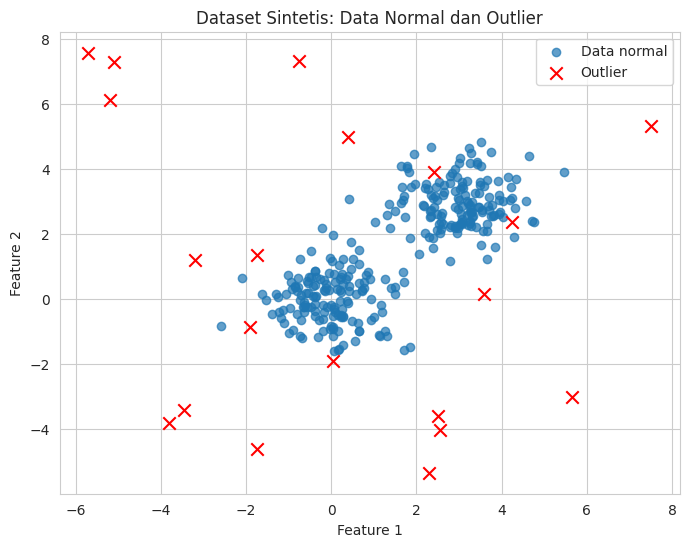

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(X_normal[:, 0], X_normal[:, 1], label="Data normal", alpha=0.7)
plt.scatter(X_outliers[:, 0], X_outliers[:, 1], label="Outlier", color="red", marker="x", s=80)
plt.title("Dataset Sintetis: Data Normal dan Outlier")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

## 3. Introduction to Outlier Detection

Salah satu pendekatan paling umum adalah membangun model yang mempelajari **pola mayoritas data**.
Setelah itu, model akan memberikan label:
- **normal**
- **outlier / anomaly**

Pada chapter ini, kita akan mencoba tiga pendekatan populer:
1. **Isolation Forest**
2. **One-Class SVM**
3. **Local Outlier Factor**

## 4. Isolation Forest

**Isolation Forest** adalah metode ensemble untuk mendeteksi outlier.
Ide utamanya sederhana:

- titik data normal biasanya berada di area padat
- outlier cenderung terisolasi dan lebih mudah dipisahkan
- model membangun banyak pohon acak untuk "mengisolasi" titik data
- titik yang cepat terisolasi dianggap lebih mungkin sebagai outlier

### Kelebihan Isolation Forest:
- cepat untuk dataset besar
- tidak terlalu sensitif terhadap skala dibanding beberapa metode lain
- sangat umum dipakai untuk anomaly detection

In [4]:
iso = IsolationForest(
    n_estimators=200,
    contamination=20/320,   # proporsi outlier kira-kira 20 dari 320 data
    random_state=42
)

iso_pred = iso.fit_predict(X_all)

print("Jumlah prediksi normal :", np.sum(iso_pred == 1))
print("Jumlah prediksi outlier:", np.sum(iso_pred == -1))

Jumlah prediksi normal : 300
Jumlah prediksi outlier: 20


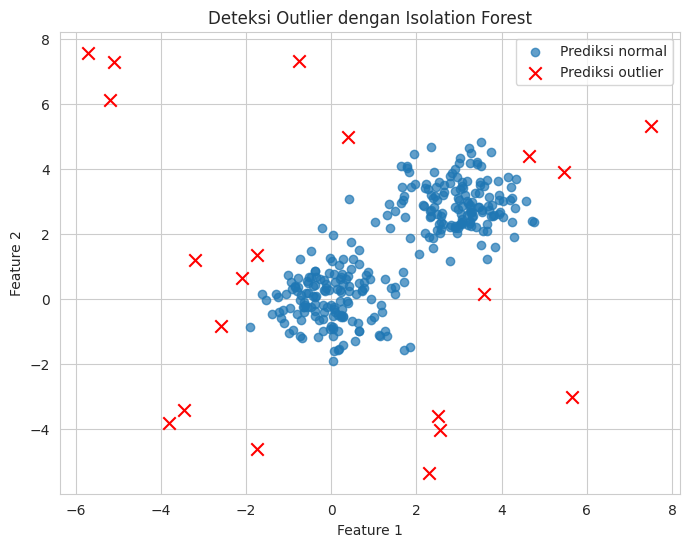

In [5]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_all[iso_pred == 1, 0],
    X_all[iso_pred == 1, 1],
    label="Prediksi normal",
    alpha=0.7
)

plt.scatter(
    X_all[iso_pred == -1, 0],
    X_all[iso_pred == -1, 1],
    label="Prediksi outlier",
    color="red",
    marker="x",
    s=80
)

plt.title("Deteksi Outlier dengan Isolation Forest")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

## 5. Evaluasi Sederhana Isolation Forest

Karena pada dataset sintetis kita mengetahui label asli (normal vs outlier),
kita bisa mengevaluasi seberapa baik Isolation Forest dalam mendeteksi anomali.

Perlu diperhatikan:
- pada praktik nyata, sering kali **label outlier tidak tersedia**
- karena itu evaluasi pada anomaly detection kadang lebih sulit dibanding supervised learning biasa

In [6]:
cm_iso = confusion_matrix(y_true, iso_pred, labels=[1, -1])

cm_iso_df = pd.DataFrame(
    cm_iso,
    index=["Aktual Normal", "Aktual Outlier"],
    columns=["Prediksi Normal", "Prediksi Outlier"]
)

cm_iso_df

,Prediksi Normal,Prediksi Outlier
Aktual Normal,296,4
Aktual Outlier,4,16


In [7]:
print("Classification report - Isolation Forest")
print(classification_report(y_true, iso_pred, target_names=["Outlier", "Normal"]))

Classification report - Isolation Forest
              precision    recall  f1-score   support

     Outlier       0.80      0.80      0.80        20
      Normal       0.99      0.99      0.99       300

    accuracy                           0.97       320
   macro avg       0.89      0.89      0.89       320
weighted avg       0.97      0.97      0.97       320



## 6. Memahami Parameter Penting Isolation Forest

Beberapa parameter penting:
- **n_estimators**: jumlah pohon dalam ensemble
- **contamination**: perkiraan proporsi outlier dalam data
- **random_state**: agar hasil reprodusibel

Parameter `contamination` penting karena model perlu tahu kira-kira berapa banyak data yang dianggap anomali.
Jika nilainya terlalu besar, data normal bisa ikut ditandai sebagai outlier.
Jika terlalu kecil, banyak outlier bisa lolos.

In [8]:
contamination_values = [0.03, 0.06, 0.10, 0.15]
results_contamination = []

for c in contamination_values:
    model = IsolationForest(
        n_estimators=200,
        contamination=c,
        random_state=42
    )
    pred = model.fit_predict(X_all)

    results_contamination.append({
        "contamination": c,
        "jumlah_outlier_terdeteksi": int(np.sum(pred == -1))
    })

pd.DataFrame(results_contamination)

,contamination,jumlah_outlier_terdeteksi
0,0.03,10
1,0.06,20
2,0.10,32
3,0.15,48


## 7. One-Class SVM untuk Novelty Detection

**One-Class SVM** biasanya digunakan untuk **novelty detection**.
Konsepnya:
- model dilatih hanya menggunakan data normal
- model belajar membentuk batas yang mencakup sebagian besar data normal
- data baru yang berada di luar batas tersebut dianggap anomali

Metode ini cocok ketika:
- kita punya banyak contoh data normal
- kita ingin mendeteksi kejadian baru yang tidak biasa

### Menyiapkan Data untuk Novelty Detection

Karena One-Class SVM diasumsikan belajar dari **data normal saja**,
kita akan:
1. memisahkan data normal sebagai data latih
2. menggabungkan data normal + outlier sebagai data uji

In [9]:
X_train_normal = X_normal.copy()
X_test_novelty = X_all.copy()
y_test_novelty = y_true.copy()

print("Train (normal only):", X_train_normal.shape)
print("Test data          :", X_test_novelty.shape)

Train (normal only): (300, 2)
Test data          : (320, 2)


In [10]:
ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.06)
ocsvm.fit(X_train_normal)

ocsvm_pred = ocsvm.predict(X_test_novelty)

print("Jumlah prediksi normal :", np.sum(ocsvm_pred == 1))
print("Jumlah prediksi outlier:", np.sum(ocsvm_pred == -1))

Jumlah prediksi normal : 285
Jumlah prediksi outlier: 35


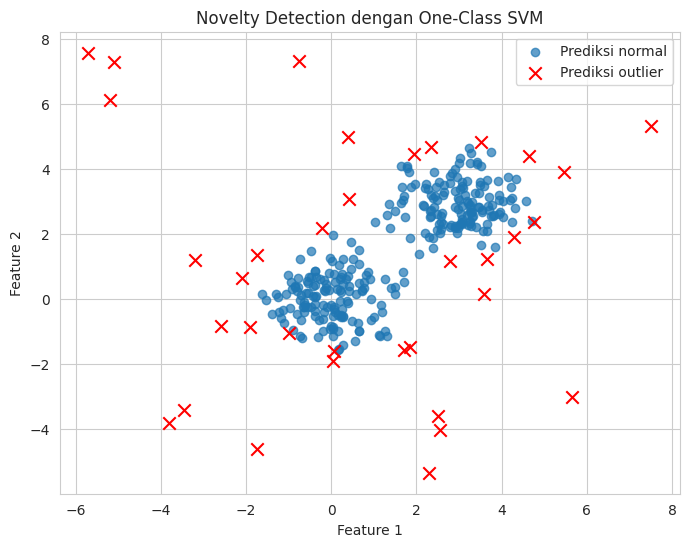

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_novelty[ocsvm_pred == 1, 0],
    X_test_novelty[ocsvm_pred == 1, 1],
    label="Prediksi normal",
    alpha=0.7
)

plt.scatter(
    X_test_novelty[ocsvm_pred == -1, 0],
    X_test_novelty[ocsvm_pred == -1, 1],
    label="Prediksi outlier",
    color="red",
    marker="x",
    s=80
)

plt.title("Novelty Detection dengan One-Class SVM")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [12]:
cm_ocsvm = confusion_matrix(y_test_novelty, ocsvm_pred, labels=[1, -1])

cm_ocsvm_df = pd.DataFrame(
    cm_ocsvm,
    index=["Aktual Normal", "Aktual Outlier"],
    columns=["Prediksi Normal", "Prediksi Outlier"]
)

cm_ocsvm_df

,Prediksi Normal,Prediksi Outlier
Aktual Normal,283,17
Aktual Outlier,2,18


In [13]:
print("Classification report - One-Class SVM")
print(classification_report(y_test_novelty, ocsvm_pred, target_names=["Outlier", "Normal"]))

Classification report - One-Class SVM
              precision    recall  f1-score   support

     Outlier       0.51      0.90      0.65        20
      Normal       0.99      0.94      0.97       300

    accuracy                           0.94       320
   macro avg       0.75      0.92      0.81       320
weighted avg       0.96      0.94      0.95       320



## 8. Parameter Penting pada One-Class SVM

Beberapa parameter penting:
- **kernel**: biasanya `rbf`
- **gamma**: mengontrol bentuk boundary
- **nu**: perkiraan proporsi outlier sekaligus batas jumlah support vectors

### Intuisi parameter:
- `gamma` besar -> boundary makin rumit
- `gamma` kecil -> boundary lebih halus
- `nu` besar -> model lebih mudah menandai data sebagai outlier

In [14]:
nu_values = [0.03, 0.05, 0.08, 0.12]
ocsvm_results = []

for nu in nu_values:
    model = OneClassSVM(kernel="rbf", gamma="scale", nu=nu)
    model.fit(X_train_normal)
    pred = model.predict(X_test_novelty)

    ocsvm_results.append({
        "nu": nu,
        "jumlah_outlier_terdeteksi": int(np.sum(pred == -1))
    })

pd.DataFrame(ocsvm_results)

,nu,jumlah_outlier_terdeteksi
0,0.03,26
1,0.05,33
2,0.08,40
3,0.12,54


## 9. Local Outlier Factor (LOF)

**Local Outlier Factor (LOF)** mendeteksi outlier dengan melihat **kepadatan lokal** suatu titik dibanding tetangganya.

Ide utamanya:
- jika sebuah titik berada di area dengan kepadatan jauh lebih rendah dibanding tetangganya,
  maka titik itu kemungkinan outlier

LOF bagus untuk kasus di mana:
- bentuk cluster tidak sederhana
- outlier hanya terlihat jika dibandingkan dengan lingkungan lokalnya

In [15]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=20/320
)

lof_pred = lof.fit_predict(X_all)

print("Jumlah prediksi normal :", np.sum(lof_pred == 1))
print("Jumlah prediksi outlier:", np.sum(lof_pred == -1))

Jumlah prediksi normal : 300
Jumlah prediksi outlier: 20


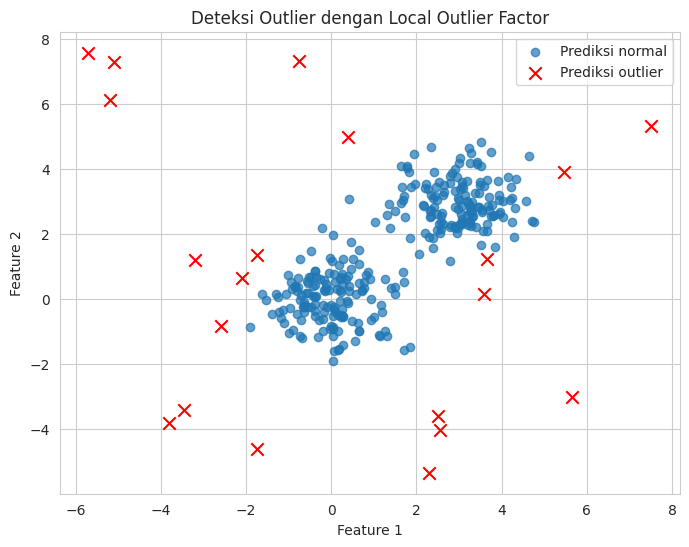

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_all[lof_pred == 1, 0],
    X_all[lof_pred == 1, 1],
    label="Prediksi normal",
    alpha=0.7
)

plt.scatter(
    X_all[lof_pred == -1, 0],
    X_all[lof_pred == -1, 1],
    label="Prediksi outlier",
    color="red",
    marker="x",
    s=80
)

plt.title("Deteksi Outlier dengan Local Outlier Factor")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [17]:
cm_lof = confusion_matrix(y_true, lof_pred, labels=[1, -1])

cm_lof_df = pd.DataFrame(
    cm_lof,
    index=["Aktual Normal", "Aktual Outlier"],
    columns=["Prediksi Normal", "Prediksi Outlier"]
)

cm_lof_df

,Prediksi Normal,Prediksi Outlier
Aktual Normal,296,4
Aktual Outlier,4,16


In [18]:
print("Classification report - LOF")
print(classification_report(y_true, lof_pred, target_names=["Outlier", "Normal"]))

Classification report - LOF
              precision    recall  f1-score   support

     Outlier       0.80      0.80      0.80        20
      Normal       0.99      0.99      0.99       300

    accuracy                           0.97       320
   macro avg       0.89      0.89      0.89       320
weighted avg       0.97      0.97      0.97       320



print("Classification report - LOF")
print(classification_report(y_true, lof_pred, target_names=["Outlier", "Normal"]))

In [19]:
def evaluate_outlier_model(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=-1),
        "Recall": recall_score(y_true, y_pred, pos_label=-1),
        "F1-Score": f1_score(y_true, y_pred, pos_label=-1)
    }

comparison_df = pd.DataFrame([
    evaluate_outlier_model(y_true, iso_pred, "Isolation Forest"),
    evaluate_outlier_model(y_test_novelty, ocsvm_pred, "One-Class SVM"),
    evaluate_outlier_model(y_true, lof_pred, "Local Outlier Factor")
])

comparison_df.sort_values("F1-Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score
0,Isolation Forest,0.975000,0.800000,0.8,0.800000
2,Local Outlier Factor,0.975000,0.800000,0.8,0.800000
1,One-Class SVM,0.940625,0.514286,0.9,0.654545


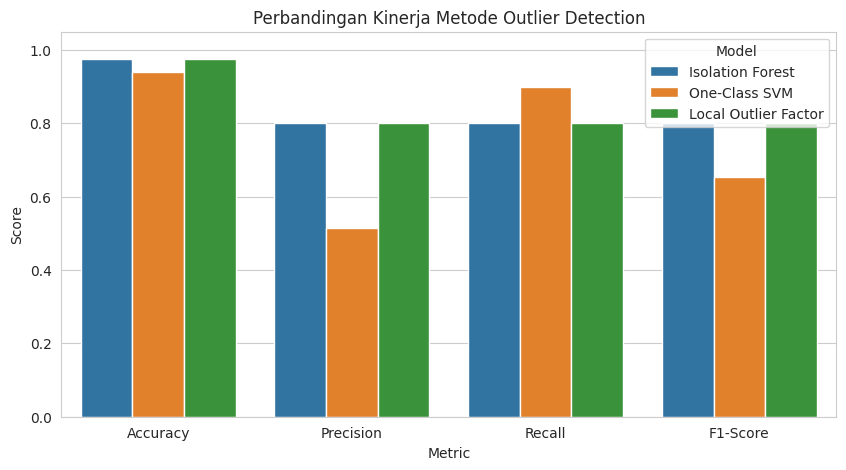

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score"),
            x="Metric", y="Score", hue="Model")
plt.title("Perbandingan Kinerja Metode Outlier Detection")
plt.ylim(0, 1.05)
plt.show()

## 11. Evaluasi pada Dataset Nyata

Sekarang kita gunakan dataset nyata dari `scikit-learn`, yaitu **Breast Cancer Wisconsin dataset**.
Dataset ini sebenarnya adalah dataset klasifikasi, bukan anomaly detection.  
Namun kita bisa menggunakannya untuk simulasi:

- anggap kelas mayoritas sebagai data normal
- anggap sebagian data minoritas sebagai "anomali"

Tujuannya adalah melihat bagaimana pipeline anomaly detection bisa diterapkan pada data nyata.

In [21]:
cancer = load_breast_cancer(as_frame=True)
df_cancer = cancer.frame.copy()

print(df_cancer.shape)
df_cancer.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [22]:
df_cancer["target"].value_counts()

,count
target,
1,357
0,212


### Menyusun skenario anomaly detection

Kita akan anggap:
- target = 1 sebagai **normal**
- target = 0 sebagai **anomali**

Ini bukan satu-satunya cara, tetapi cukup baik untuk demonstrasi konsep.

In [23]:
X_cancer = df_cancer.drop(columns="target")
y_cancer = df_cancer["target"].copy()

# Ubah label menjadi format anomaly detection:
# 1 = normal
# -1 = outlier/anomali
y_cancer_outlier = y_cancer.map({1: 1, 0: -1})

print(y_cancer_outlier.value_counts())

target
 1    357
-1    212
Name: count, dtype: int64


In [24]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer,
    y_cancer_outlier,
    test_size=0.25,
    random_state=42,
    stratify=y_cancer_outlier
)

print("Train shape:", X_train_c.shape)
print("Test shape :", X_test_c.shape)

Train shape: (426, 30)
Test shape : (143, 30)


## 12. Isolation Forest pada Dataset Nyata

Untuk data numerik nyata, scaling sering membantu beberapa metode,
walaupun Isolation Forest sendiri tidak selalu sepeka SVM terhadap skala.
Agar konsisten, kita akan memakai `StandardScaler`.

In [25]:
pipe_iso = Pipeline([
    ("scaler", StandardScaler()),
    ("iso", IsolationForest(contamination=0.37, random_state=42))
])

pipe_iso.fit(X_train_c)
pred_cancer_iso = pipe_iso.predict(X_test_c)

print("Accuracy :", round(accuracy_score(y_test_c, pred_cancer_iso), 3))
print("Precision:", round(precision_score(y_test_c, pred_cancer_iso, pos_label=-1), 3))
print("Recall   :", round(recall_score(y_test_c, pred_cancer_iso, pos_label=-1), 3))
print("F1 Score :", round(f1_score(y_test_c, pred_cancer_iso, pos_label=-1), 3))

Accuracy : 0.783
Precision: 0.712
Recall   : 0.698
F1 Score : 0.705


In [26]:
cm = confusion_matrix(y_test_c, pred_cancer_iso, labels=[1, -1])
cm_df = pd.DataFrame(
    cm,
    index=["Aktual Normal", "Aktual Anomali"],
    columns=["Prediksi Normal", "Prediksi Anomali"]
)
cm_df

,Prediksi Normal,Prediksi Anomali
Aktual Normal,75,15
Aktual Anomali,16,37


## 13. One-Class SVM pada Dataset Nyata

Untuk novelty detection, kita latih model hanya pada data normal.
Artinya:
- training hanya memakai sampel dengan label normal
- testing memakai campuran data normal dan anomali

In [27]:
X_train_normal_c = X_train_c[y_train_c == 1]
X_test_mix_c = X_test_c.copy()
y_test_mix_c = y_test_c.copy()

print("Train normal only:", X_train_normal_c.shape)
print("Test mixed data  :", X_test_mix_c.shape)

Train normal only: (267, 30)
Test mixed data  : (143, 30)


In [28]:
pipe_ocsvm = Pipeline([
    ("scaler", StandardScaler()),
    ("ocsvm", OneClassSVM(kernel="rbf", gamma="scale", nu=0.35))
])

pipe_ocsvm.fit(X_train_normal_c)
pred_cancer_ocsvm = pipe_ocsvm.predict(X_test_mix_c)

print("Accuracy :", round(accuracy_score(y_test_mix_c, pred_cancer_ocsvm), 3))
print("Precision:", round(precision_score(y_test_mix_c, pred_cancer_ocsvm, pos_label=-1), 3))
print("Recall   :", round(recall_score(y_test_mix_c, pred_cancer_ocsvm, pos_label=-1), 3))
print("F1 Score :", round(f1_score(y_test_mix_c, pred_cancer_ocsvm, pos_label=-1), 3))

Accuracy : 0.783
Precision: 0.631
Recall   : 1.0
F1 Score : 0.774


In [29]:
cm = confusion_matrix(y_test_mix_c, pred_cancer_ocsvm, labels=[1, -1])
cm_df = pd.DataFrame(
    cm,
    index=["Aktual Normal", "Aktual Anomali"],
    columns=["Prediksi Normal", "Prediksi Anomali"]
)
cm_df

,Prediksi Normal,Prediksi Anomali
Aktual Normal,59,31
Aktual Anomali,0,53


## 14. Local Outlier Factor pada Dataset Nyata

LOF akan melihat kepadatan lokal setiap titik.  
Metode ini sering berguna ketika distribusi data tidak seragam.

In [30]:
X_train_scaled = StandardScaler().fit_transform(X_train_c)
X_test_scaled = StandardScaler().fit_transform(X_test_c)

lof_real = LocalOutlierFactor(n_neighbors=20, contamination=0.37, novelty=True)
lof_real.fit(X_train_scaled)

pred_cancer_lof = lof_real.predict(X_test_scaled)

print("Accuracy :", round(accuracy_score(y_test_c, pred_cancer_lof), 3))
print("Precision:", round(precision_score(y_test_c, pred_cancer_lof, pos_label=-1), 3))
print("Recall   :", round(recall_score(y_test_c, pred_cancer_lof, pos_label=-1), 3))
print("F1 Score :", round(f1_score(y_test_c, pred_cancer_lof, pos_label=-1), 3))

Accuracy : 0.51
Precision: 0.369
Recall   : 0.453
F1 Score : 0.407


In [31]:
cm = confusion_matrix(y_test_c, pred_cancer_lof, labels=[1, -1])
cm_df = pd.DataFrame(
    cm,
    index=["Aktual Normal", "Aktual Anomali"],
    columns=["Prediksi Normal", "Prediksi Anomali"]
)
cm_df

,Prediksi Normal,Prediksi Anomali
Aktual Normal,49,41
Aktual Anomali,29,24


## 15. Ringkasan Perbandingan pada Dataset Nyata

In [32]:
real_comparison = pd.DataFrame([
    evaluate_outlier_model(y_test_c, pred_cancer_iso, "Isolation Forest"),
    evaluate_outlier_model(y_test_mix_c, pred_cancer_ocsvm, "One-Class SVM"),
    evaluate_outlier_model(y_test_c, pred_cancer_lof, "Local Outlier Factor")
])

real_comparison.sort_values("F1-Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score
1,One-Class SVM,0.783217,0.630952,1.000000,0.773723
0,Isolation Forest,0.783217,0.711538,0.698113,0.704762
2,Local Outlier Factor,0.510490,0.369231,0.452830,0.406780


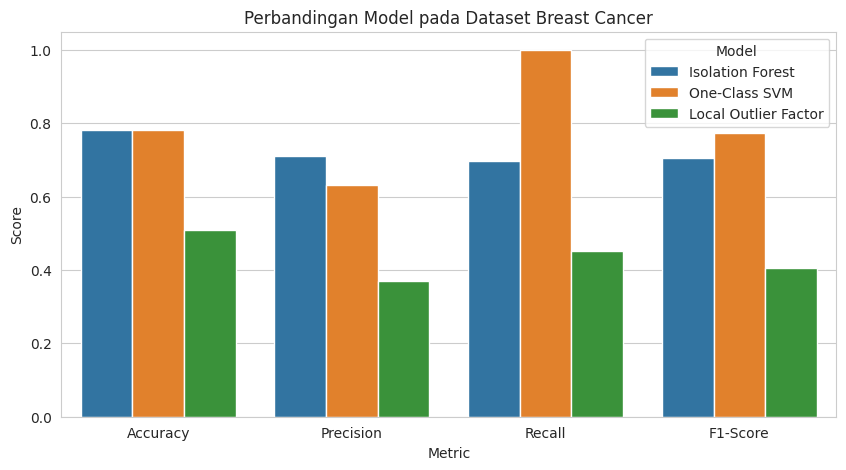

In [33]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=real_comparison.melt(id_vars="Model", var_name="Metric", value_name="Score"),
    x="Metric", y="Score", hue="Model"
)
plt.title("Perbandingan Model pada Dataset Breast Cancer")
plt.ylim(0, 1.05)
plt.show()

## 16. Menangani Outlier yang Terdeteksi

Setelah outlier ditemukan, ada beberapa strategi umum:
1. **Menghapus outlier**
2. **Menandai outlier sebagai flag/fitur tambahan**
3. **Melakukan winsorization / clipping**
4. **Mengecek ulang apakah outlier adalah kesalahan data atau kejadian penting**
5. **Memakai model yang robust terhadap outlier**

Pada bagian ini, kita akan mencoba strategi sederhana: menghapus data yang dideteksi sebagai outlier dari data training.

In [34]:
# Gunakan Isolation Forest untuk menandai outlier pada training set
iso_cleaner = IsolationForest(contamination=0.05, random_state=42)
train_pred_clean = iso_cleaner.fit_predict(X_train_c)

# Ambil hanya data yang dianggap normal
X_train_clean = X_train_c[train_pred_clean == 1]
y_train_clean = y_train_c[train_pred_clean == 1]

print("Ukuran train sebelum cleaning:", X_train_c.shape)
print("Ukuran train sesudah cleaning:", X_train_clean.shape)

Ukuran train sebelum cleaning: (426, 30)
Ukuran train sesudah cleaning: (404, 30)


# Gunakan Isolation Forest untuk menandai outlier pada training set
iso_cleaner = IsolationForest(contamination=0.05, random_state=42)
train_pred_clean = iso_cleaner.fit_predict(X_train_c)

# Ambil hanya data yang dianggap normal
X_train_clean = X_train_c[train_pred_clean == 1]
y_train_clean = y_train_c[train_pred_clean == 1]

print("Ukuran train sebelum cleaning:", X_train_c.shape)
print("Ukuran train sesudah cleaning:", X_train_clean.shape)

In [35]:
from sklearn.linear_model import LogisticRegression

# Model sebelum cleaning
pipe_before = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000))
])

pipe_before.fit(X_train_c, y_train_c)
score_before = pipe_before.score(X_test_c, y_test_c)

# Model sesudah cleaning
pipe_after = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000))
])

pipe_after.fit(X_train_clean, y_train_clean)
score_after = pipe_after.score(X_test_c, y_test_c)

print("Akurasi sebelum cleaning:", round(score_before, 4))
print("Akurasi sesudah cleaning:", round(score_after, 4))

Akurasi sebelum cleaning: 0.986
Akurasi sesudah cleaning: 0.986


## 17. Interpretasi Hasil Cleaning

Jika performa model naik setelah outlier dihapus, maka kemungkinan outlier memang mengganggu proses pembelajaran model.

Namun, menghapus outlier tidak selalu benar karena:
- outlier bisa jadi merupakan kejadian penting
- outlier bisa mengandung informasi bisnis yang sangat bernilai
- pada fraud detection, justru data langka sering menjadi target utama

Karena itu, penanganan outlier harus mempertimbangkan konteks masalah.

## 18. Kapan Menggunakan Metode Tertentu?

### Isolation Forest
Cocok jika:
- dataset cukup besar
- ingin metode cepat
- butuh baseline anomaly detection yang kuat

### One-Class SVM
Cocok jika:
- kita memiliki data normal yang cukup representatif
- ingin novelty detection
- ukuran data tidak terlalu besar

### Local Outlier Factor
Cocok jika:
- outlier ditentukan oleh kepadatan lokal
- bentuk distribusi data cukup kompleks
- ingin membandingkan tiap titik dengan tetangga terdekatnya

## 19. Kelebihan dan Kekurangan Metode

### Isolation Forest
**Kelebihan**
- cepat
- scalable
- bagus untuk anomaly detection umum

**Kekurangan**
- pemilihan contamination penting
- tidak selalu optimal jika struktur data sangat lokal

### One-Class SVM
**Kelebihan**
- bagus untuk novelty detection
- dapat membentuk decision boundary non-linear

**Kekurangan**
- sensitif terhadap scaling
- bisa lambat untuk data besar
- sensitif terhadap parameter `nu` dan `gamma`

### LOF
**Kelebihan**
- kuat untuk mendeteksi outlier lokal
- baik untuk distribusi yang tidak seragam

**Kekurangan**
- lebih sulit diskalakan
- sensitif terhadap jumlah tetangga

## 20. Practical Exercise 1 - Isolation Forest pada Data Sintetis Baru

Sekarang kita buat dataset baru dan menerapkan Isolation Forest kembali untuk memperkuat pemahaman.

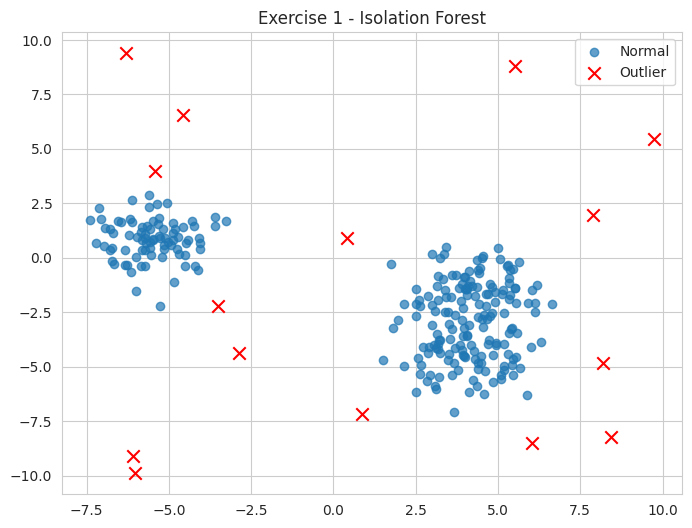

In [36]:
X_blob2, _ = make_blobs(
    n_samples=250,
    centers=3,
    cluster_std=1.0,
    random_state=123
)

X_out2 = np.random.uniform(low=-10, high=10, size=(15, 2))
X_mix2 = np.vstack([X_blob2, X_out2])
y_mix2 = np.hstack([np.ones(len(X_blob2)), -np.ones(len(X_out2))])

iso2 = IsolationForest(contamination=15/265, random_state=123)
pred2 = iso2.fit_predict(X_mix2)

plt.figure(figsize=(8, 6))
plt.scatter(X_mix2[pred2 == 1, 0], X_mix2[pred2 == 1, 1], alpha=0.7, label="Normal")
plt.scatter(X_mix2[pred2 == -1, 0], X_mix2[pred2 == -1, 1], color="red", marker="x", s=80, label="Outlier")
plt.title("Exercise 1 - Isolation Forest")
plt.legend()
plt.show()

## 21. Practical Exercise 2 - LOF pada Data Moon

Dataset `make_moons` memiliki bentuk non-linear sehingga menarik untuk diuji dengan LOF.

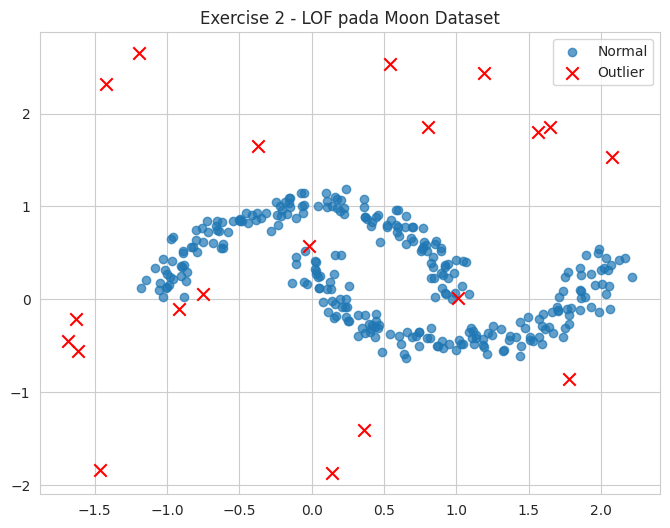

In [37]:
X_moon, _ = make_moons(n_samples=300, noise=0.08, random_state=42)
moon_outliers = np.random.uniform(low=-2, high=3, size=(20, 2))

X_moon_all = np.vstack([X_moon, moon_outliers])
y_moon_all = np.hstack([np.ones(len(X_moon)), -np.ones(len(moon_outliers))])

lof_moon = LocalOutlierFactor(n_neighbors=20, contamination=20/320)
pred_moon = lof_moon.fit_predict(X_moon_all)

plt.figure(figsize=(8, 6))
plt.scatter(X_moon_all[pred_moon == 1, 0], X_moon_all[pred_moon == 1, 1], alpha=0.7, label="Normal")
plt.scatter(X_moon_all[pred_moon == -1, 0], X_moon_all[pred_moon == -1, 1], color="red", marker="x", s=80, label="Outlier")
plt.title("Exercise 2 - LOF pada Moon Dataset")
plt.legend()
plt.show()

## 22. Practical Exercise 3 - One-Class SVM pada Data Normal

Latih One-Class SVM hanya pada data normal, lalu uji dengan data campuran.

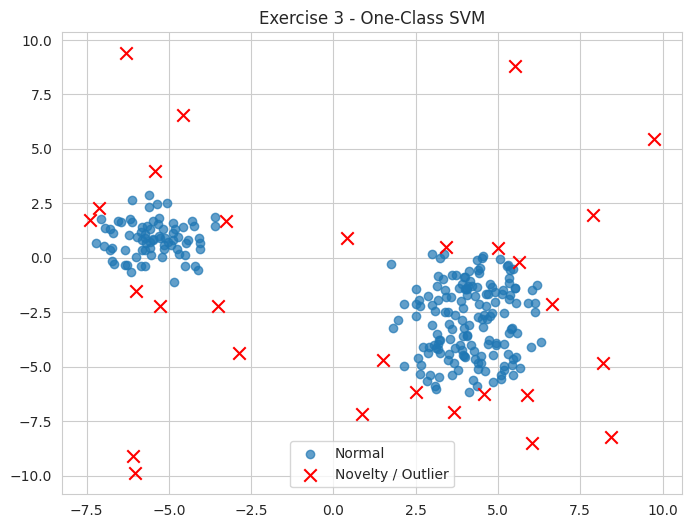

In [38]:
X_train_ex = X_blob2.copy()
X_test_ex = X_mix2.copy()
y_test_ex = y_mix2.copy()

svm_ex = OneClassSVM(kernel="rbf", gamma="scale", nu=0.06)
svm_ex.fit(X_train_ex)
pred_ex = svm_ex.predict(X_test_ex)

plt.figure(figsize=(8, 6))
plt.scatter(X_test_ex[pred_ex == 1, 0], X_test_ex[pred_ex == 1, 1], alpha=0.7, label="Normal")
plt.scatter(X_test_ex[pred_ex == -1, 0], X_test_ex[pred_ex == -1, 1], color="red", marker="x", s=80, label="Novelty / Outlier")
plt.title("Exercise 3 - One-Class SVM")
plt.legend()
plt.show()

## 23. Ringkasan Chapter 11

Pada chapter ini, kita mempelajari bahwa:
- **Outlier detection** bertujuan menemukan titik data yang menyimpang dari pola umum
- **Novelty detection** digunakan untuk mendeteksi data baru yang tidak sesuai dengan pola normal
- **Isolation Forest** efektif dan cepat untuk anomaly detection umum
- **One-Class SVM** cocok untuk novelty detection jika data training berisi data normal
- **Local Outlier Factor** fokus pada kepadatan lokal dan cocok untuk mendeteksi outlier lokal
- Evaluasi anomaly detection dapat menggunakan:
  - confusion matrix
  - precision
  - recall
  - f1-score
- Penanganan outlier harus hati-hati karena outlier tidak selalu berarti data salah

## 24. Kesimpulan

Deteksi outlier merupakan bagian penting dalam machine learning karena data menyimpang dapat:
- menurunkan performa model
- mengubah distribusi data
- memengaruhi interpretasi analisis

Namun, outlier juga bisa menjadi sinyal penting, misalnya:
- transaksi fraud
- serangan jaringan
- kerusakan sensor
- kesalahan produksi

Karena itu, pemilihan metode seperti **Isolation Forest**, **One-Class SVM**, atau **LOF**
harus disesuaikan dengan:
- bentuk data
- ukuran dataset
- apakah kita punya data normal saja atau data campuran
- tujuan analisis (cleaning, monitoring, fraud detection, atau novelty detection)